# Text Summarization — Encoder-Decoder LSTM + Atención (Luong) + Embeddings spaCy

## 0. Verificar GPU

In [1]:
import subprocess, sys

def check_gpu():
    try:
        result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total,driver_version',
                                 '--format=csv,noheader'], capture_output=True, text=True)
        if result.returncode == 0:
            print("✅ GPU detectada:", result.stdout.strip())
        else:
            print("⚠️  No se detectó GPU. Actívala en: Entorno de ejecución → Cambiar tipo → GPU")
    except FileNotFoundError:
        print("⚠️  nvidia-smi no disponible.")

check_gpu()


✅ GPU detectada: Tesla T4, 15360 MiB, 580.82.07


## 1. Instalación de dependencias

In [4]:
import subprocess, sys

pkgs = [
    "numpy==1.26.4",
    "datasets==2.19.0",
    "evaluate",
    "rouge_score",
    "spacy==3.7.4",
    "tf-keras",
]

for pkg in pkgs:
    print(f"Instalando {pkg} ...")
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", pkg],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print(f"❌ FALLÓ: {pkg}\n{result.stderr[-1000:]}")
    else:
        print(f"✅ {pkg}")

# spaCy model
result = subprocess.run(
    [sys.executable, "-m", "spacy", "download", "en_core_web_md"],
    capture_output=True, text=True
)
if result.returncode != 0:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "https://github.com/explosion/spacy-models/releases/download/"
         "en_core_web_md-3.7.1/en_core_web_md-3.7.1-py3-none-any.whl"],
        check=True
    )

print("OK")

Instalando numpy==1.26.4 ...
✅ numpy==1.26.4
Instalando datasets==2.19.0 ...
✅ datasets==2.19.0
Instalando evaluate ...
✅ evaluate
Instalando rouge_score ...
✅ rouge_score
Instalando spacy==3.7.4 ...
✅ spacy==3.7.4
Instalando tf-keras ...
✅ tf-keras
OK


## 2. Imports y configuración GPU

In [5]:
import os, re, pickle, subprocess
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, LSTM, Dense, Embedding,
                                      Attention, Concatenate, TimeDistributed)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import spacy
from datasets import load_dataset
import evaluate
import matplotlib.pyplot as plt

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"✅ GPU disponible: {len(gpus)} dispositivo(s)")
    print("   ", [g.name for g in gpus])
    PROFILE = 'gpu'
else:
    print("⚠️  Corriendo en CPU — considera activar GPU.")
    PROFILE = 'cpu'

print(f"TensorFlow version: {tf.__version__}")


✅ GPU disponible: 1 dispositivo(s)
    ['/physical_device:GPU:0']
TensorFlow version: 2.20.0


## 3. Configuración global

Modifica aquí los hiperparámetros. Los valores `gpu` están calibrados para T4 (16 GB VRAM).


In [14]:
CFG = {
    'SAVE_PATH': '/content/model_summ/',

    'DATASET_NAME':    'cnn_dailymail',
    'DATASET_VERSION': '3.0.0',
    'N_TRAIN': 5_000  if PROFILE == 'cpu' else 50_000,
    'N_VAL':   500    if PROFILE == 'cpu' else 5_000,
    'N_TEST':  200    if PROFILE == 'cpu' else 2_000,

    'MAX_LEN_ART': 150 if PROFILE == 'cpu' else 400,
    'MAX_LEN_SUM': 40  if PROFILE == 'cpu' else 80,
    'VOCAB_ART':   20_000 if PROFILE == 'cpu' else 50_000,
    'VOCAB_SUM':   10_000 if PROFILE == 'cpu' else 25_000,

    'EMB_DIM':       300,
    'SPACY_MODEL':   'en_core_web_md',
    'EMB_TRAINABLE': False,

    'LATENT_DIM': 256 if PROFILE == 'cpu' else 512,
    'DROPOUT':    0.3,

    'BATCH_SIZE':    32  if PROFILE == 'cpu' else 132,
    'EPOCHS':        5   if PROFILE == 'cpu' else 30,
    'LEARNING_RATE': 1e-3,
    'PATIENCE_ES':   4,    # EarlyStopping
    'PATIENCE_LR':   2,    # ReduceLROnPlateau

    'N_EVAL': 50 if PROFILE == 'cpu' else 500,
}

os.makedirs(CFG['SAVE_PATH'], exist_ok=True)
print(f"PROFILE = {PROFILE}")
for k, v in CFG.items():
    print(f"  {k}: {v}")


PROFILE = gpu
  SAVE_PATH: /content/model_summ/
  DATASET_NAME: cnn_dailymail
  DATASET_VERSION: 3.0.0
  N_TRAIN: 50000
  N_VAL: 5000
  N_TEST: 2000
  MAX_LEN_ART: 400
  MAX_LEN_SUM: 80
  VOCAB_ART: 50000
  VOCAB_SUM: 25000
  EMB_DIM: 300
  SPACY_MODEL: en_core_web_md
  EMB_TRAINABLE: False
  LATENT_DIM: 512
  DROPOUT: 0.3
  BATCH_SIZE: 132
  EPOCHS: 30
  LEARNING_RATE: 0.001
  PATIENCE_ES: 4
  PATIENCE_LR: 2
  N_EVAL: 500


## 4. Carga del dataset

In [7]:
ds = load_dataset(CFG['DATASET_NAME'], CFG['DATASET_VERSION'])
print(ds)

train_raw = ds['train'].select(range(CFG['N_TRAIN']))
val_raw   = ds['validation'].select(range(CFG['N_VAL']))
test_raw  = ds['test'].select(range(CFG['N_TEST']))

print(f"\nTrain: {len(train_raw)} | Val: {len(val_raw)} | Test: {len(test_raw)}")
print("\nEjemplo — Article:", train_raw[0]['article'][:300], "...")
print("\nEjemplo — Highlights:", train_raw[0]['highlights'])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/287113 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/13368 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11490 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 287113
    })
    validation: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 13368
    })
    test: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 11490
    })
})

Train: 50000 | Val: 5000 | Test: 2000

Ejemplo — Article: LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 million) fortune as he turns 18 on Monday, but he insists the money won't cast a spell on him. Daniel Radcliffe as Harry Potter in "Harry Potter and the Order of the Phoenix" To the disappoi ...

Ejemplo — Highlights: Harry Potter star Daniel Radcliffe gets £20M fortune as he turns 18 Monday .
Young actor says he has no plans to fritter his cash away .
Radcliffe's earnings from first five Potter films have been held in trust fund .


## 5. Preprocesamiento

In [8]:
def clean(s):
    s = s.lower().strip()
    s = re.sub(r'\(cnn\)', ' ', s)
    s = re.sub(r"[^a-z0-9?.!,'\" ]+", ' ', s)
    s = re.sub(r'\s+', ' ', s)
    return s.strip()

def truncate_words(s, n):
    return ' '.join(s.split()[:n])

def prep(split):
    arts, sums = [], []
    for ex in split:
        a = truncate_words(clean(ex['article']),    CFG['MAX_LEN_ART'])
        s = truncate_words(clean(ex['highlights']), CFG['MAX_LEN_SUM'] - 2)
        if not a or not s:
            continue
        arts.append(a)
        sums.append('<start> ' + s + ' <end>')
    return arts, sums

train_arts, train_sums = prep(train_raw)
val_arts,   val_sums   = prep(val_raw)
test_arts,  test_sums  = prep(test_raw)

print(f"Train={len(train_arts)} | Val={len(val_arts)} | Test={len(test_arts)}")


Train=50000 | Val=5000 | Test=2000


In [9]:
art_tok = Tokenizer(num_words=CFG['VOCAB_ART'], oov_token='<unk>', filters='')
art_tok.fit_on_texts(train_arts)

sum_tok = Tokenizer(num_words=CFG['VOCAB_SUM'], oov_token='<unk>', filters='')
sum_tok.fit_on_texts(train_sums)

def encode(arts, sums):
    X = pad_sequences(art_tok.texts_to_sequences(arts),
                      maxlen=CFG['MAX_LEN_ART'], padding='post', truncating='post')
    Y = pad_sequences(sum_tok.texts_to_sequences(sums),
                      maxlen=CFG['MAX_LEN_SUM'], padding='post', truncating='post')
    return X, Y

X_train, Y_train = encode(train_arts, train_sums)
X_val,   Y_val   = encode(val_arts,   val_sums)

Y_train_target = np.zeros_like(Y_train); Y_train_target[:, :-1] = Y_train[:, 1:]
Y_val_target   = np.zeros_like(Y_val);   Y_val_target[:, :-1]   = Y_val[:, 1:]

art_vocab = min(CFG['VOCAB_ART'], len(art_tok.word_index) + 1)
sum_vocab = min(CFG['VOCAB_SUM'], len(sum_tok.word_index) + 1)

print(f"art_vocab={art_vocab}  sum_vocab={sum_vocab}")
print(f"X_train={X_train.shape}  Y_train={Y_train.shape}")

with open(os.path.join(CFG['SAVE_PATH'], 'art_tok.pkl'), 'wb') as f: pickle.dump(art_tok, f)
with open(os.path.join(CFG['SAVE_PATH'], 'sum_tok.pkl'), 'wb') as f: pickle.dump(sum_tok, f)

art_vocab=50000  sum_vocab=25000
X_train=(50000, 400)  Y_train=(50000, 80)


## 6. Embeddings preentrenados (spaCy)

In [10]:
nlp_en = spacy.load(CFG['SPACY_MODEL'])
print("✅ spaCy cargado.")

def build_emb_matrix(tokenizer, vocab_size, dim):
    M = np.zeros((vocab_size, dim), dtype=np.float32)
    hits = 0
    for word, i in tokenizer.word_index.items():
        if i >= vocab_size:
            continue
        v = nlp_en(word).vector
        if v.any():
            M[i] = v
            hits += 1
    print(f"  cobertura: {hits}/{vocab_size} ({100*hits/vocab_size:.1f}%)")
    return M

print("Encoder embeddings:")
emb_art = build_emb_matrix(art_tok, art_vocab, CFG['EMB_DIM'])
print("Decoder embeddings:")
emb_sum = build_emb_matrix(sum_tok, sum_vocab, CFG['EMB_DIM'])


✅ spaCy cargado.
Encoder embeddings:
  cobertura: 46319/50000 (92.6%)
Decoder embeddings:
  cobertura: 22872/25000 (91.5%)


## 7. Modelo Encoder-Decoder + Atención (Luong)


In [12]:
from tensorflow.keras.layers import Dropout, Bidirectional

if gpus:
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
    print("✅ Mixed precision activada (float16)")
else:
    print("ℹ️  Mixed precision desactivada (CPU)")

encoder_inputs = Input(shape=(CFG['MAX_LEN_ART'],), name='Enc_Input')
enc_emb = Embedding(art_vocab, CFG['EMB_DIM'], weights=[emb_art],
                    trainable=CFG['EMB_TRAINABLE'], mask_zero=False,
                    name='Enc_Emb')(encoder_inputs)
enc_emb = Dropout(CFG['DROPOUT'])(enc_emb)

enc_lstm_fwd = LSTM(CFG['LATENT_DIM'], return_sequences=True, return_state=True,
                    name='Enc_LSTM_Fwd')
encoder_outputs_fwd, state_h_fwd, state_c_fwd = enc_lstm_fwd(enc_emb)



# Decoder
decoder_inputs = Input(shape=(CFG['MAX_LEN_SUM'],), name='Dec_Input')
dec_emb_layer = Embedding(sum_vocab, CFG['EMB_DIM'], weights=[emb_sum],
                           trainable=CFG['EMB_TRAINABLE'], mask_zero=False,
                           name='Dec_Emb')
dec_emb = dec_emb_layer(decoder_inputs)
dec_emb = Dropout(CFG['DROPOUT'])(dec_emb)

decoder_lstm = LSTM(CFG['LATENT_DIM'], return_sequences=True, return_state=True,
                    name='Dec_LSTM')
decoder_outputs, _, _ = decoder_lstm(dec_emb,
                                      initial_state=[state_h_fwd, state_c_fwd])



# Atención Luong
attn_layer = Attention(name='Luong_Attn')
attn_out = attn_layer([decoder_outputs, encoder_outputs_fwd])

concat = Concatenate(axis=-1, name='Concat')([decoder_outputs, attn_out])
concat = Dropout(CFG['DROPOUT'])(concat)



decoder_dense = TimeDistributed(
    Dense(sum_vocab, activation='softmax', dtype='float32'), name='Out')
decoder_pred = decoder_dense(concat)

model = Model([encoder_inputs, decoder_inputs], decoder_pred)

optimizer = tf.keras.optimizers.Adam(learning_rate=CFG['LEARNING_RATE'])
model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()


✅ Mixed precision activada (float16)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Enc_Input           │ (None, 400)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dec_Input           │ (None, 80)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Enc_Emb (Embedding) │ (None, 400, 300)  │ 15,000,000 │ Enc_Input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dec_Emb (Embedding) │ (None, 80, 300)   │  7,500,000 │ Dec_Input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 400, 300)  │          0 │ Enc_Emb[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 80, 300)   │          0 │ Dec_Emb[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Enc_LSTM_Fwd (LSTM) │ [(None, 400,      │  1,665,024 │ dropout[0][0]     │
│                     │ 512), (None,      │            │                   │
│                     │ 512), (None,      │            │                   │
│                     │ 512)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dec_LSTM (LSTM)     │ [(None, 80, 512), │  1,665,024 │ dropout_1[0][0],  │
│                     │ (None, 512),      │            │ Enc_LSTM_Fwd[0][… │
│                     │ (None, 512)]      │            │ Enc_LSTM_Fwd[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Luong_Attn          │ (None, 80, 512)   │          0 │ Dec_LSTM[0][0],   │
│ (Attention)         │                   │            │ Enc_LSTM_Fwd[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Concat              │ (None, 80, 1024)  │          0 │ Dec_LSTM[0][0],   │
│ (Concatenate)       │                   │            │ Luong_Attn[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 80, 1024)  │          0 │ Concat[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Out                 │ (None, 80, 25000) │ 25,625,000 │ dropout_2[0][0]   │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 51,455,048 (196.29 MB)

 Trainable params: 28,955,048 (110.45 MB)

 Non-trainable params: 22,500,000 (85.83 MB)

## 8. Entrenamiento

Callbacks incluidos:
- **EarlyStopping** — detiene si val_loss no mejora
- **ReduceLROnPlateau** — baja lr cuando el loss se estanca
- **ModelCheckpoint** — guarda el mejor modelo automáticamente


In [15]:
ckpt_path = os.path.join(CFG['SAVE_PATH'], 'best_model.keras')

callbacks = [
    EarlyStopping(monitor='val_loss', patience=CFG['PATIENCE_ES'],
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=CFG['PATIENCE_LR'], min_lr=1e-6, verbose=1),
    ModelCheckpoint(ckpt_path, monitor='val_loss', save_best_only=True, verbose=1),
]

def make_dataset(X, Y, Y_target, batch_size, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(
        ({'Enc_Input': X, 'Dec_Input': Y}, Y_target)
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=min(10_000, len(X)))
    ds = (ds
          .batch(batch_size)
          .prefetch(tf.data.AUTOTUNE))
    return ds

train_ds = make_dataset(X_train, Y_train, Y_train_target, CFG['BATCH_SIZE'], shuffle=True)
val_ds   = make_dataset(X_val,   Y_val,   Y_val_target,   CFG['BATCH_SIZE'], shuffle=False)

print(f"Pasos por época (train): {len(train_ds)}")
print(f"Pasos por época (val):   {len(val_ds)}")
print("\n🚀 Iniciando entrenamiento...")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CFG['EPOCHS'],
    callbacks=callbacks,
)

print("\n✅ Entrenamiento finalizado.")

Pasos por época (train): 379
Pasos por época (val):   38

🚀 Iniciando entrenamiento...
Epoch 1/30
379/379 ━━━━━━━━━━━━━━━━━━━━ 0s 771ms/step - accuracy: 0.4692 - loss: 4.4927
Epoch 1: val_loss improved from None to 3.40706, saving model to /content/model_summ/best_model.keras

Epoch 1: finished saving model to /content/model_summ/best_model.keras
379/379 ━━━━━━━━━━━━━━━━━━━━ 323s 841ms/step - accuracy: 0.4996 - loss: 3.8538 - val_accuracy: 0.5083 - val_loss: 3.4071 - learning_rate: 0.0010
Epoch 2/30
379/379 ━━━━━━━━━━━━━━━━━━━━ 0s 768ms/step - accuracy: 0.5299 - loss: 3.3420
Epoch 2: val_loss improved from 3.40706 to 3.23116, saving model to /content/model_summ/best_model.keras

Epoch 2: finished saving model to /content/model_summ/best_model.keras
379/379 ━━━━━━━━━━━━━━━━━━━━ 325s 857ms/step - accuracy: 0.5277 - loss: 3.2929 - val_accuracy: 0.5155 - val_loss: 3.2312 - learning_rate: 0.0010
Epoch 3/30
379/379 ━━━━━━━━━━━━━━━━━━━━ 0s 767ms/step - accuracy: 0.5376 - loss: 3.1327
Epoch 3:

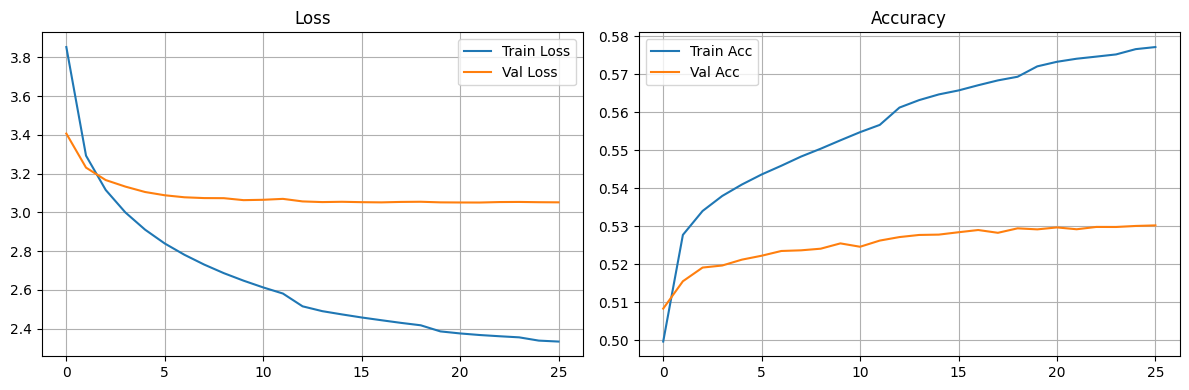

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['accuracy'],     label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(CFG['SAVE_PATH'], 'training_curves.png'), dpi=150)
plt.show()


## 9. Inferencia (greedy decoding)

In [17]:
start_idx = sum_tok.word_index.get('<start>', 1)
end_idx   = sum_tok.word_index.get('<end>', 2)
idx2word  = {i: w for w, i in sum_tok.word_index.items()}

def summarize(text, max_len=None):
    max_len = max_len or CFG['MAX_LEN_SUM']
    text = truncate_words(clean(text), CFG['MAX_LEN_ART'])
    x = pad_sequences(art_tok.texts_to_sequences([text]),
                      maxlen=CFG['MAX_LEN_ART'], padding='post', truncating='post')
    dec_in = np.zeros((1, CFG['MAX_LEN_SUM']), dtype=np.int32)
    dec_in[0, 0] = start_idx

    out_tokens = []
    for t in range(1, max_len):
        preds = model.predict([x, dec_in], verbose=0)
        next_id = int(np.argmax(preds[0, t - 1, :]))
        if next_id in (end_idx, 0):
            break
        word = idx2word.get(next_id, '')
        if word and word not in ('<start>', '<end>', '<unk>'):
            out_tokens.append(word)
        dec_in[0, t] = next_id
    return ' '.join(out_tokens)

# Prueba rápida
for i in range(3):
    art = test_raw[i]['article']
    ref = test_raw[i]['highlights']
    pred = summarize(art)
    print('=' * 80)
    print('ARTICLE:', art[:300], '...')
    print('REF    :', ref)
    print('PRED   :', pred)


ARTICLE: (CNN)The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisdiction over alleged crimes in Palestinian territories. The formal accession was marked with a ceremony at The Hague, in the Netherlands, where the cou ...
REF    : Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since last June .
Israel and the United States opposed the move, which could open the door to war crimes investigations against Israelis .
PRED   : new the icc says the icc is a sufficient to be a warrant . the icc is accused of crimes against humanity and crimes against humanity . the icc is accused of crimes against humanity and crimes against humanity . the icc is accused of crimes against humanity and crimes against humanity .
ARTICLE: (CNN)Never mind cats having nine lives. A stray pooch in Washington State has used up at least three of her own after being hit by a car, 

## 10. Evaluación con ROUGE

In [21]:
rouge = evaluate.load('rouge')

preds, refs = [], []
print(f"Generando {int(CFG['N_EVAL']/10)} resúmenes para evaluación...")
for i in range(int(CFG['N_EVAL']/10)
):
    if i % 50 == 0:
        print(f"  {i}/{int(CFG['N_EVAL']/10)}")
    preds.append(summarize(test_raw[i]['article']))
    refs.append(test_raw[i]['highlights'].lower())

scores = rouge.compute(predictions=preds, references=refs)
print("\n📊 ROUGE — Modelo Propio (LSTM + Atención):")
print(f"{'Métrica':<12} {'Score':>8}")
print("-" * 22)
for k, v in sorted(scores.items()):
    print(f"  {k:<10} {v:>8.4f}")

# Guardar scores para comparación en el otro notebook
import json
with open(os.path.join(CFG['SAVE_PATH'], 'scores_lstm.json'), 'w') as f:
    json.dump(scores, f, indent=2)
print("\nScores guardados en scores_lstm.json")


Generando 50 resúmenes para evaluación...
  0/50

📊 ROUGE — Modelo Propio (LSTM + Atención):
Métrica         Score
----------------------
  rouge1       0.1261
  rouge2       0.0113
  rougeL       0.1143
  rougeLsum    0.1217

Scores guardados en scores_lstm.json


## 11. Probar con texto propio

In [19]:
my_article = """
NASA's Perseverance rover has successfully collected its first rock sample
from Mars, marking a major milestone in the agency's mission to search for
ancient signs of microbial life on the Red Planet. The sample, taken from
a rock nicknamed 'Rochette', was sealed in a titanium tube and stored on
the rover for eventual return to Earth in a future mission. Scientists
hope the sample will provide clues about whether Mars once harbored life
billions of years ago when the planet had liquid water.
"""

print("=== MODELO PROPIO (LSTM + Atención) ===")
print(summarize(my_article))


=== MODELO PROPIO (LSTM + Atención) ===
the spacex dragon is the first time to be a . the rover was a
